In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    friedmanchisquare,
    rankdata,
    wilcoxon,
)

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SYNTHETIC_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
)

GLM_METRICS_PATH = (
    SYNTHETIC_RESULTS_DIR
    / "glm"
    / "glm_synthetic_metrics.csv"
)

MLP_METRICS_PATH = (
    SYNTHETIC_RESULTS_DIR
    / "mlp"
    / "mlp_synthetic_metrics.csv"
)

PINN_METRICS_PATH = (
    SYNTHETIC_RESULTS_DIR
    / "pinn"
    / "pinn_synthetic_metrics.csv"
)

COMPARISON_DIR = (
    SYNTHETIC_RESULTS_DIR
    / "comparison"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for name, path in {
    "GLM": GLM_METRICS_PATH,
    "MLP": MLP_METRICS_PATH,
    "PINN": PINN_METRICS_PATH,
}.items():
    print(name, path.exists(), path)

GLM True /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/glm/glm_synthetic_metrics.csv
MLP True /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/mlp/mlp_synthetic_metrics.csv
PINN True /content/drive/MyDrive/Proyecto_PINN_HRF/results/synthetic/pinn/pinn_synthetic_metrics.csv


In [4]:
glm_metrics = pd.read_csv(
    GLM_METRICS_PATH
)

mlp_metrics = pd.read_csv(
    MLP_METRICS_PATH
)

pinn_metrics = pd.read_csv(
    PINN_METRICS_PATH
)

print("GLM:", len(glm_metrics))
print("MLP:", len(mlp_metrics))
print("PINN:", len(pinn_metrics))

GLM: 60
MLP: 60
PINN: 60


In [5]:
KEY_COLUMNS = [
    "scenario",
    "snr_name",
    "target_snr",
    "replicate",
]

for model_name, table in {
    "GLM": glm_metrics,
    "MLP": mlp_metrics,
    "PINN": pinn_metrics,
}.items():
    duplicated = table.duplicated(
        KEY_COLUMNS
    ).sum()

    print(
        model_name,
        "duplicados:",
        duplicated,
    )

    if duplicated != 0:
        raise ValueError(
            f"{model_name} contiene claves duplicadas."
        )

GLM duplicados: 0
MLP duplicados: 0
PINN duplicados: 0


In [6]:
METRIC_COLUMNS = [
    "test_rmse_percent",
    "test_mae_percent",
    "test_r2",
    "test_pearson_r",
    "hrf_rmse_percent",
    "hrf_r2",
    "hrf_pearson_r",
]

def preparar_tabla_modelo(
    table: pd.DataFrame,
    model_name: str,
) -> pd.DataFrame:
    selected = table[
        KEY_COLUMNS
        + METRIC_COLUMNS
    ].copy()

    selected["model"] = model_name

    return selected

In [7]:
comparison_long = pd.concat(
    [
        preparar_tabla_modelo(
            glm_metrics,
            "GLM",
        ),
        preparar_tabla_modelo(
            mlp_metrics,
            "MLP",
        ),
        preparar_tabla_modelo(
            pinn_metrics,
            "PINN",
        ),
    ],
    ignore_index=True,
)

print(
    "Filas de la tabla larga:",
    len(comparison_long),
)

display(
    comparison_long.head()
)

Filas de la tabla larga: 180


,scenario,snr_name,target_snr,replicate,test_rmse_percent,test_mae_percent,test_r2,test_pearson_r,hrf_rmse_percent,hrf_r2,hrf_pearson_r,model
0,motor_lr_m1_left,snr_10,10.0,1,0.396317,0.281541,0.683353,0.829357,0.122291,0.335814,0.593488,GLM
1,motor_lr_m1_left,snr_10,10.0,2,0.397635,0.284248,0.681244,0.829238,0.122244,0.336327,0.593488,GLM
2,motor_lr_m1_left,snr_10,10.0,3,0.400630,0.284093,0.676424,0.826814,0.122110,0.337780,0.593488,GLM
3,motor_lr_m1_left,snr_10,10.0,4,0.400266,0.287362,0.677012,0.828244,0.122364,0.335028,0.593488,GLM
4,motor_lr_m1_left,snr_10,10.0,5,0.402015,0.293102,0.674183,0.829498,0.122479,0.333777,0.593488,GLM


In [8]:
count_validation = (
    comparison_long
    .groupby(
        KEY_COLUMNS
    )["model"]
    .nunique()
)

if not (
    count_validation == 3
).all():
    raise ValueError(
        "No todas las instancias contienen "
        "los tres modelos."
    )

print(
    "Las 60 instancias contienen "
    "GLM, MLP y PINN."
)

Las 60 instancias contienen GLM, MLP y PINN.


In [9]:
descriptive_summary = (
    comparison_long
    .groupby(
        [
            "model",
            "target_snr",
        ],
        as_index=False,
    )
    .agg(
        n=(
            "test_rmse_percent",
            "size",
        ),
        test_rmse_mean=(
            "test_rmse_percent",
            "mean",
        ),
        test_rmse_std=(
            "test_rmse_percent",
            "std",
        ),
        test_rmse_median=(
            "test_rmse_percent",
            "median",
        ),
        test_r2_mean=(
            "test_r2",
            "mean",
        ),
        test_r2_std=(
            "test_r2",
            "std",
        ),
        hrf_rmse_mean=(
            "hrf_rmse_percent",
            "mean",
        ),
        hrf_rmse_std=(
            "hrf_rmse_percent",
            "std",
        ),
        hrf_r2_mean=(
            "hrf_r2",
            "mean",
        ),
        hrf_r2_std=(
            "hrf_r2",
            "std",
        ),
    )
    .sort_values(
        [
            "target_snr",
            "model",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

descriptive_summary.to_csv(
    COMPARISON_DIR
    / "synthetic_model_summary.csv",
    index=False,
)

display(descriptive_summary)

,model,target_snr,n,test_rmse_mean,test_rmse_std,test_rmse_median,test_r2_mean,test_r2_std,hrf_rmse_mean,hrf_rmse_std,hrf_r2_mean,hrf_r2_std
2,GLM,10.0,20,0.405537,0.005207,0.405906,0.668407,0.008512,0.122234,0.000196,0.336438,0.002129
5,MLP,10.0,20,0.084914,0.032849,0.085911,0.983398,0.014353,0.241800,0.024992,-1.622980,0.534181
8,PINN,10.0,20,0.057740,0.023428,0.055237,0.992228,0.006462,0.012376,0.004652,0.992284,0.005982
1,GLM,5.0,20,0.409851,0.005560,0.408169,0.661308,0.009204,0.122241,0.000290,0.336363,0.003145
4,MLP,5.0,20,0.108782,0.029163,0.102221,0.974516,0.014804,0.237348,0.024724,-1.527684,0.529269
7,PINN,5.0,20,0.065453,0.026332,0.063536,0.990036,0.007621,0.013915,0.005346,0.990194,0.007164
0,GLM,2.0,20,0.418684,0.020289,0.412174,0.645825,0.034660,0.122222,0.000564,0.336552,0.006142
3,MLP,2.0,20,0.210325,0.047071,0.208065,0.906578,0.045303,0.242118,0.037532,-1.662893,0.806467
6,PINN,2.0,20,0.079970,0.042812,0.074235,0.983597,0.017170,0.018141,0.008191,0.982553,0.014915


In [10]:
def holm_correction(
    p_values: list[float],
) -> np.ndarray:
    """
    Ajusta valores p mediante el método secuencial
    de Holm.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    n_tests = len(p_values)

    order = np.argsort(
        p_values
    )

    adjusted_sorted = np.empty(
        n_tests,
        dtype=float,
    )

    running_maximum = 0.0

    for rank, index in enumerate(order):
        adjusted = (
            (n_tests - rank)
            * p_values[index]
        )

        running_maximum = max(
            running_maximum,
            adjusted,
        )

        adjusted_sorted[rank] = min(
            running_maximum,
            1.0,
        )

    adjusted = np.empty(
        n_tests,
        dtype=float,
    )

    adjusted[order] = adjusted_sorted

    return adjusted

In [11]:
def rank_biserial_paired(
    first: np.ndarray,
    second: np.ndarray,
) -> float:
    """
    Tamaño de efecto para diferencias pareadas.

    Un valor positivo indica que first presenta
    valores mayores que second.
    """
    differences = np.asarray(
        first,
        dtype=float,
    ) - np.asarray(
        second,
        dtype=float,
    )

    differences = differences[
        ~np.isclose(
            differences,
            0.0,
        )
    ]

    if len(differences) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(differences)
    )

    positive_sum = np.sum(
        ranks[
            differences > 0
        ]
    )

    negative_sum = np.sum(
        ranks[
            differences < 0
        ]
    )

    return float(
        (
            positive_sum
            - negative_sum
        )
        / (
            positive_sum
            + negative_sum
        )
    )

In [12]:
MODEL_PAIRS = [
    ("GLM", "MLP"),
    ("GLM", "PINN"),
    ("MLP", "PINN"),
]

METRICS_TO_TEST = [
    "test_rmse_percent",
    "hrf_rmse_percent",
]

friedman_rows = []
wilcoxon_rows = []

for target_snr in sorted(
    comparison_long[
        "target_snr"
    ].unique(),
    reverse=True,
):
    snr_table = comparison_long.loc[
        comparison_long[
            "target_snr"
        ] == target_snr
    ].copy()

    for metric in METRICS_TO_TEST:
        wide = snr_table.pivot(
            index=KEY_COLUMNS,
            columns="model",
            values=metric,
        ).dropna()

        statistic, p_value = (
            friedmanchisquare(
                wide["GLM"],
                wide["MLP"],
                wide["PINN"],
            )
        )

        friedman_rows.append(
            {
                "target_snr": target_snr,
                "metric": metric,
                "n_pairs": len(wide),
                "friedman_statistic": float(
                    statistic
                ),
                "p_value": float(
                    p_value
                ),
            }
        )

        temporary_rows = []
        temporary_p_values = []

        for first_model, second_model in MODEL_PAIRS:
            first_values = wide[
                first_model
            ].to_numpy(dtype=float)

            second_values = wide[
                second_model
            ].to_numpy(dtype=float)

            wilcoxon_result = wilcoxon(
                first_values,
                second_values,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto",
            )

            paired_difference = (
                first_values
                - second_values
            )

            temporary_rows.append(
                {
                    "target_snr": target_snr,
                    "metric": metric,
                    "first_model": first_model,
                    "second_model": second_model,
                    "n_pairs": len(wide),
                    "first_mean": float(
                        np.mean(
                            first_values
                        )
                    ),
                    "second_mean": float(
                        np.mean(
                            second_values
                        )
                    ),
                    "mean_difference": float(
                        np.mean(
                            paired_difference
                        )
                    ),
                    "median_difference": float(
                        np.median(
                            paired_difference
                        )
                    ),
                    "wilcoxon_statistic": float(
                        wilcoxon_result.statistic
                    ),
                    "p_value_raw": float(
                        wilcoxon_result.pvalue
                    ),
                    "rank_biserial": (
                        rank_biserial_paired(
                            first_values,
                            second_values,
                        )
                    ),
                }
            )

            temporary_p_values.append(
                wilcoxon_result.pvalue
            )

        adjusted_p_values = holm_correction(
            temporary_p_values
        )

        for row, adjusted_p in zip(
            temporary_rows,
            adjusted_p_values,
        ):
            row["p_value_holm"] = float(
                adjusted_p
            )

            wilcoxon_rows.append(row)

In [13]:
friedman_results = pd.DataFrame(
    friedman_rows
)

wilcoxon_results = pd.DataFrame(
    wilcoxon_rows
)

friedman_results.to_csv(
    COMPARISON_DIR
    / "friedman_tests.csv",
    index=False,
)

wilcoxon_results.to_csv(
    COMPARISON_DIR
    / "wilcoxon_pairwise_holm.csv",
    index=False,
)

print("Pruebas de Friedman:")
display(friedman_results)

print("Comparaciones pareadas:")
display(wilcoxon_results)

Pruebas de Friedman:


,target_snr,metric,n_pairs,friedman_statistic,p_value
0,10.0,test_rmse_percent,20,32.5,8.764248e-08
1,10.0,hrf_rmse_percent,20,40.0,2.061154e-09
2,5.0,test_rmse_percent,20,36.4,1.246925e-08
3,5.0,hrf_rmse_percent,20,40.0,2.061154e-09
4,2.0,test_rmse_percent,20,40.0,2.061154e-09
5,2.0,hrf_rmse_percent,20,40.0,2.061154e-09


Comparaciones pareadas:


,target_snr,metric,first_model,second_model,n_pairs,first_mean,second_mean,mean_difference,median_difference,wilcoxon_statistic,p_value_raw,rank_biserial,p_value_holm
0,10.0,test_rmse_percent,GLM,MLP,20,0.405537,0.084914,0.320623,0.323460,0.0,0.000002,1.000000,0.000006
1,10.0,test_rmse_percent,GLM,PINN,20,0.405537,0.057740,0.347797,0.351181,0.0,0.000002,1.000000,0.000006
2,10.0,test_rmse_percent,MLP,PINN,20,0.084914,0.057740,0.027174,0.027167,27.0,0.002325,0.742857,0.002325
3,10.0,hrf_rmse_percent,GLM,MLP,20,0.122234,0.241800,-0.119566,-0.118954,0.0,0.000002,-1.000000,0.000006
4,10.0,hrf_rmse_percent,GLM,PINN,20,0.122234,0.012376,0.109857,0.110454,0.0,0.000002,1.000000,0.000006
5,10.0,hrf_rmse_percent,MLP,PINN,20,0.241800,0.012376,0.229423,0.228071,0.0,0.000002,1.000000,0.000006
6,5.0,test_rmse_percent,GLM,MLP,20,0.409851,0.108782,0.301069,0.308272,0.0,0.000002,1.000000,0.000006
7,5.0,test_rmse_percent,GLM,PINN,20,0.409851,0.065453,0.344398,0.345550,0.0,0.000002,1.000000,0.000006
8,5.0,test_rmse_percent,MLP,PINN,20,0.108782,0.065453,0.043329,0.034961,13.0,0.000168,0.876190,0.000168
9,5.0,hrf_rmse_percent,GLM,MLP,20,0.122241,0.237348,-0.115107,-0.113353,0.0,0.000002,-1.000000,0.000006


In [14]:
paired_metrics = comparison_long.pivot(
    index=KEY_COLUMNS,
    columns="model",
    values=[
        "test_rmse_percent",
        "hrf_rmse_percent",
    ],
)

improvement_rows = []

for target_snr in sorted(
    comparison_long[
        "target_snr"
    ].unique(),
    reverse=True,
):
    selected = paired_metrics.loc[
        paired_metrics.index.get_level_values(
            "target_snr"
        ) == target_snr
    ]

    for baseline_model in [
        "GLM",
        "MLP",
    ]:
        signal_improvement = (
            100.0
            * (
                selected[
                    (
                        "test_rmse_percent",
                        baseline_model,
                    )
                ]
                - selected[
                    (
                        "test_rmse_percent",
                        "PINN",
                    )
                ]
            )
            / selected[
                (
                    "test_rmse_percent",
                    baseline_model,
                )
            ]
        )

        hrf_improvement = (
            100.0
            * (
                selected[
                    (
                        "hrf_rmse_percent",
                        baseline_model,
                    )
                ]
                - selected[
                    (
                        "hrf_rmse_percent",
                        "PINN",
                    )
                ]
            )
            / selected[
                (
                    "hrf_rmse_percent",
                    baseline_model,
                )
            ]
        )

        improvement_rows.append(
            {
                "target_snr": target_snr,
                "baseline": baseline_model,
                "signal_rmse_reduction_mean_percent": float(
                    signal_improvement.mean()
                ),
                "signal_rmse_reduction_median_percent": float(
                    signal_improvement.median()
                ),
                "hrf_rmse_reduction_mean_percent": float(
                    hrf_improvement.mean()
                ),
                "hrf_rmse_reduction_median_percent": float(
                    hrf_improvement.median()
                ),
            }
        )

improvement_summary = pd.DataFrame(
    improvement_rows
)

improvement_summary.to_csv(
    COMPARISON_DIR
    / "pinn_relative_improvements.csv",
    index=False,
)

display(improvement_summary)

,target_snr,baseline,signal_rmse_reduction_mean_percent,signal_rmse_reduction_median_percent,hrf_rmse_reduction_mean_percent,hrf_rmse_reduction_median_percent
0,10.0,GLM,85.780579,86.412817,89.874795,90.414998
1,10.0,MLP,25.971386,33.215871,94.833796,95.097960
2,5.0,GLM,84.023154,84.523024,88.620202,89.125075
3,5.0,MLP,35.343266,31.511913,94.096958,94.097785
4,2.0,GLM,80.951547,81.896823,85.179187,85.236656
5,2.0,MLP,60.652938,68.533294,92.052444,92.721917


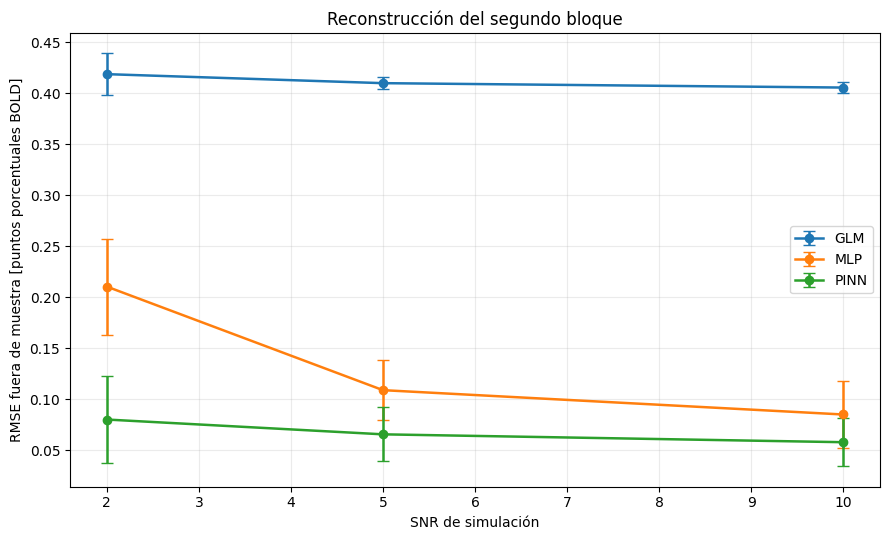

In [15]:
plot_summary = (
    descriptive_summary
    .sort_values(
        "target_snr"
    )
)

plt.figure(figsize=(9, 5.5))

for model_name in [
    "GLM",
    "MLP",
    "PINN",
]:
    model_data = plot_summary.loc[
        plot_summary[
            "model"
        ] == model_name
    ]

    plt.errorbar(
        model_data["target_snr"],
        model_data["test_rmse_mean"],
        yerr=model_data["test_rmse_std"],
        marker="o",
        capsize=4,
        linewidth=1.8,
        label=model_name,
    )

plt.xlabel("SNR de simulación")
plt.ylabel(
    "RMSE fuera de muestra "
    "[puntos porcentuales BOLD]"
)
plt.title(
    "Reconstrucción del segundo bloque"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "synthetic_models_test_rmse_vs_snr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

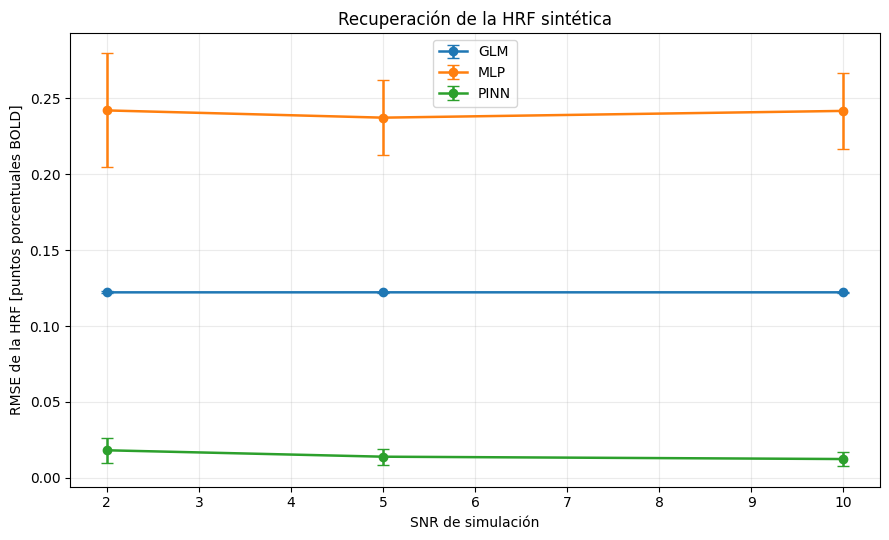

In [16]:
plt.figure(figsize=(9, 5.5))

for model_name in [
    "GLM",
    "MLP",
    "PINN",
]:
    model_data = plot_summary.loc[
        plot_summary[
            "model"
        ] == model_name
    ]

    plt.errorbar(
        model_data["target_snr"],
        model_data["hrf_rmse_mean"],
        yerr=model_data["hrf_rmse_std"],
        marker="o",
        capsize=4,
        linewidth=1.8,
        label=model_name,
    )

plt.xlabel("SNR de simulación")
plt.ylabel(
    "RMSE de la HRF "
    "[puntos porcentuales BOLD]"
)
plt.title(
    "Recuperación de la HRF sintética"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "synthetic_models_hrf_rmse_vs_snr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [17]:
parameter_summary = (
    pinn_metrics
    .groupby(
        "target_snr",
        as_index=False,
    )
    .agg(
        epsilon_mean=(
            "epsilon_relative_error_percent",
            "mean",
        ),
        epsilon_std=(
            "epsilon_relative_error_percent",
            "std",
        ),
        tau_mean=(
            "tau_relative_error_percent",
            "mean",
        ),
        tau_std=(
            "tau_relative_error_percent",
            "std",
        ),
        alpha_mean=(
            "alpha_relative_error_percent",
            "mean",
        ),
        alpha_std=(
            "alpha_relative_error_percent",
            "std",
        ),
    )
    .sort_values(
        "target_snr"
    )
)

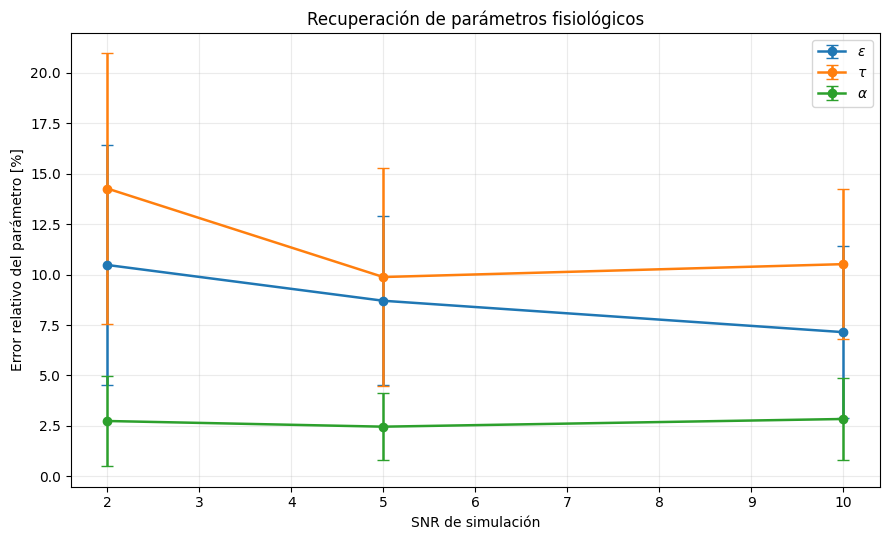

In [18]:
plt.figure(figsize=(9, 5.5))

for parameter_name, label in [
    ("epsilon", r"$\epsilon$"),
    ("tau", r"$\tau$"),
    ("alpha", r"$\alpha$"),
]:
    plt.errorbar(
        parameter_summary[
            "target_snr"
        ],
        parameter_summary[
            f"{parameter_name}_mean"
        ],
        yerr=parameter_summary[
            f"{parameter_name}_std"
        ],
        marker="o",
        capsize=4,
        linewidth=1.8,
        label=label,
    )

plt.xlabel("SNR de simulación")
plt.ylabel(
    "Error relativo del parámetro [%]"
)
plt.title(
    "Recuperación de parámetros fisiológicos"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "pinn_parameter_error_vs_snr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()